# Feature selection: choosing informative features

Feature selection decides which measured genes define PCA and the neighborhood graph. Highly
variable genes (HVGs) help focus the analysis on differences among cells while reducing the
computational cost of using every measured gene. The goal is to retain informative variation
without letting broadly expressed or noisy genes dominate the comparison.

CyteArc's `features.hvgs` models the relationship between mean expression and variance, then selects
genes whose corrected variance is high relative to genes with similar abundance. This matters
because a highly expressed gene can have a large raw variance without distinguishing cell types.

This is distinct from cell quality control.
A gene can be measured correctly and still be excluded because it contributes broad technical or confounding variation to the graph.

## Fit the mean-variance model

The PBMC store carries an analysis saved as `docs_default`. It used 500 genes and 15 PCs to keep
this teaching example small. The current API defaults are 1,000 genes and 21 PCs.
We first repeat the saved 500-gene selection to inspect how those genes were chosen.

In [1]:
# Compare selected genes in tables and embedding plots.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cytearc

# Keep routine progress messages out of the teaching output.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example, including its saved analysis.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq", destination="cytearc_datasets", zarr=True
)

Started: 2026-10-08T11:03:17.244402Z | Wall time: 5.193 s

Open the downloaded store and its saved analysis.

In [2]:
# Open the datastore for the following analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the prepared baseline for the comparisons below.
baseline = ds.pipeline.open(label="docs_default")

# Reuse the run's frozen analysis cells.
cell_selection = baseline["analysis_cell_selection"]

# Inspect the opened assays and their dimensions.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-08T11:03:22.440755Z | Wall time: 3.544 s

Fit and inspect the 500-gene selection used by the saved example.

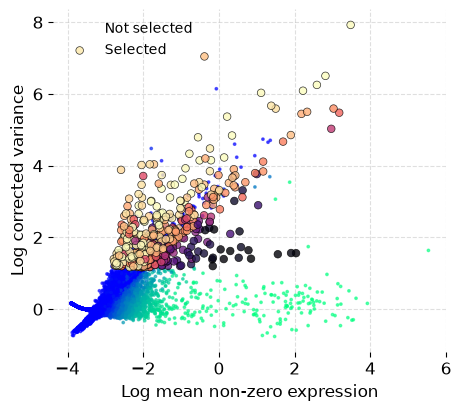

{'matches docs_default': True, 'selected genes': 500}

Started: 2026-10-08T11:03:25.987498Z | Wall time: 1.242 s

In [3]:
# Select the same 500 genes used by the prepared baseline.
hvg_500 = ds.features.hvgs(cell_selection, top_n=500)

# Load the selected-gene mask on the full feature axis.
hvg_500_values = np.asarray(ds.artifacts.load(hvg_500)["values"][:])

# Check agreement with the saved selection and its gene count.
{
    "matches docs_default": hvg_500 == baseline["highly_variable_features"],
    "selected genes": int(hvg_500_values.sum()),
}

The plot should retain genes above the fitted mean-variance trend across a useful expression range.
A selection concentrated only among the most abundant genes can make library size or housekeeping programs dominate the graph.

## Understand the default exclusions

CyteArc applies the following case-insensitive regular expression to gene names:

```text
^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|
^XIST$|^DDX3Y$|^USP9Y$|^EIF1AY$|^KDM5D$|^SRY$|^ZFY$|^UTY$|^TMSB4Y$|^NLGN4Y$
```

Matching starts at the beginning of the name.
Each family is defined once in `cytearc.features.gene_families`; `ribosomal` covers RPS, RPL, MRPS, and MRPL.
Count how many genes in this dataset fall into each family:

In [4]:
# Inspect the gene families used by the default exclusion pattern.
from cytearc.features.gene_families import GENE_FAMILY_PATTERNS
from cytearc.features.variability import DEFAULT_HVG_BLACKLIST

# Count genes matching each default exclusion family.
family_counts = pd.Series(
    {
        name: len(ds.RNA.feats.grep(pattern))
        for name, pattern in GENE_FAMILY_PATTERNS.items()
    },
    name="genes matching pattern",
)

# Count all genes matched by the combined default blacklist.
print("Default blacklist matches:", len(ds.RNA.feats.grep(DEFAULT_HVG_BLACKLIST)))

# Inspect which excluded gene families are represented in the assay.
family_counts

Default blacklist matches: 329


mitochondrial     13
ribosomal        184
cellCycleCcn      31
hla               20
h2                 0
histone           71
sexLinked         10
Name: genes matching pattern, dtype: int64

Started: 2026-10-08T11:03:27.233668Z | Wall time: 0.395 s

These families can dominate broad variation associated with sequencing depth, cell quality,
cell state, or sex without representing the cell identities sought in a typical heterogeneity
workflow. Mitochondrial, ribosomal, and sex-linked genes can still be biologically relevant to
your question. Treat the default as a starting point and decide which programs the graph should
capture before excluding them.

By default, `max_cells` is `n_selected - 20`.
Genes detected in at least that many selected cells are excluded as nearly ubiquitous.

Clearing the blacklist keeps every gene name while retaining other HVG filters.
Compare the same `top_n` with and without the default pattern:

In [5]:
# Repeat selection with the same count and no name blacklist.
hvg_no_blacklist = ds.features.hvgs(
    cell_selection, top_n=500, blacklist="", show_plot=False
)

# Load the alternative selection on the same feature axis.
unblocked_values = np.asarray(ds.artifacts.load(hvg_no_blacklist)["values"][:])

# Keep both feature masks for a direct comparison.
selection_values = {
    "hvgs_default": hvg_500_values,
    "hvgs_no_blacklist": unblocked_values,
}

# Compare selected-gene counts with and without name exclusions.
pd.Series(
    {key: int(values.sum()) for key, values in selection_values.items()},
    name="selected genes",
)

hvgs_default         500
hvgs_no_blacklist    500
Name: selected genes, dtype: int64

Started: 2026-10-08T11:03:27.632366Z | Wall time: 1.686 s

In [6]:
# Read gene names on the full feature axis.
feature_names = ds.RNA.feats.fetch_all("names")

# Keep the default selection mask.
default_values = selection_values["hvgs_default"]

# Find genes added only when the blacklist is cleared.
only_without_blacklist = feature_names[unblocked_values & ~default_values]

# Count genes added only when the blacklist is cleared.
print(
    "Genes selected only when blacklist is cleared:", len(only_without_blacklist)
)

# Inspect the newly included gene names.
pd.Series(only_without_blacklist).head(15)

Genes selected only when blacklist is cleared: 11


0     HIST1H2AC
1     HIST1H2BJ
2      HIST1H3H
3       HLA-DRA
4      HLA-DRB1
5      HLA-DQA1
6      HLA-DQB1
7       HLA-DMB
8       HLA-DMA
9      HLA-DPA1
10     HLA-DPB1
dtype: str

Started: 2026-10-08T11:03:29.324238Z | Wall time: 0.035 s

Other overrides stay available for study-specific work:

```python
# Replace the default with a study-specific, case-insensitive regex.
ds.features.hvgs(cell_selection, blacklist=r"^MT-|^RPS|^RPL", top_n=2000)

# Disable the nearly ubiquitous gene filter.
ds.features.hvgs(cell_selection, max_cells=np.inf, top_n=2000)
```

Repeating a selection with the same cells and settings reuses the saved result, including the
diagnostics used for its plot. See [](reuse_and_tracing.ipynb) for details.

## Compare feature-set size

The number of selected genes changes the PCA basis and can change neighbourhood structure.
This comparison keeps all other graph choices fixed. The 500-gene branch comes directly from
`docs_default`; only the 1,000-gene branch is new.

In [7]:
# Select 1,000 genes on the same frozen cell population.
feature_1000 = ds.features.hvgs(cell_selection, top_n=1000, show_plot=False)

# Read the selected-gene mask for the new branch.
feature_1000_values = np.asarray(ds.artifacts.load(feature_1000)["values"][:])

# Check the number of genes retained for the new branch.
{"selected genes": int(feature_1000_values.sum())}

{'selected genes': 1000}

Started: 2026-10-08T11:03:29.363043Z | Wall time: 1.527 s

Normalize the selected genes and construct the new graph.

In [8]:
# Normalize the new feature selection.
normalized_1000 = ds.features.normalize(cell_selection, feature_1000)

# Keep 15 PCA dimensions for this feature-count comparison.
pca_1000 = ds.reduction.pca(normalized_1000, dims=15)

# Prepare the embedding initialization from the new PCA.
initialization_1000 = ds.embeddings.initialization(pca_1000)

# Build a neighbor-search index for the new PCA.
ann_1000 = ds.graph.ann_index(pca_1000)

# Keep the baseline neighbor count of 11.
neighbors_1000 = ds.graph.neighbors(ann_1000, k=11)

# Build connectivity from the new neighbors.
graph_1000 = ds.graph.connectivity(neighbors_1000)

# Read the PCA dimensions supplied to this graph without loading its values.
pca_shape = ds.artifacts.load(pca_1000)["data"].shape

# Inspect the cell and principal-component counts.
{"cells": pca_shape[0], "PCs": pca_shape[1]}

{'cells': 3948, 'PCs': 15}

Started: 2026-10-08T11:03:30.892771Z | Wall time: 29.362 s

Build the layout and clustering for the new graph.

In [9]:
# Pair the layout and clustering for each feature count.
feature_branches = {
    500: (baseline["umap"], baseline["leiden_0.5"]),
    1000: (
        ds.embeddings.umap(graph_1000, initialization_1000),
        ds.clusters.leiden(graph_1000, resolution=0.5),
    ),
}

# Read the dimensions of the saved layout for each feature count.
layout_shapes = {
    top_n: ds.artifacts.load(layout_ref)["values"].shape
    for top_n, (layout_ref, _) in feature_branches.items()
}

# Check that both layouts contain the same cells and two embedding coordinates.
pd.DataFrame(
    layout_shapes, index=["cells", "embedding dimensions"]
).T.rename_axis("selected genes")

,cells,embedding dimensions
selected genes,,
500,3948,2
1000,3948,2


Started: 2026-10-08T11:04:00.256973Z | Wall time: 6.350 s

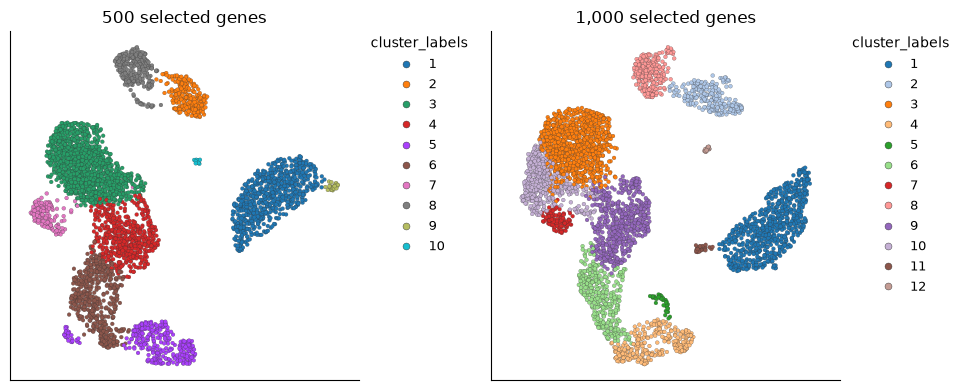

Started: 2026-10-08T11:04:06.610156Z | Wall time: 1.403 s

In [10]:
# Create one plotting axis for each comparison panel.
figure, axes = plt.subplots(1, 2, figsize=(10, 4))

# Retain the cluster labels from each plotted feature branch.
cluster_values = {}

# Draw each comparison on its own labeled axis.
for axis, top_n in zip(axes, feature_branches, strict=True):

    # Select this branch's layout and cluster labels.
    umap_ref, cluster_ref = feature_branches[top_n]

    # Read the cluster labels for this branch.
    labels = np.asarray(ds.artifacts.load(cluster_ref)["values"][:])

    # Retain those labels for the cross-tabulation below.
    cluster_values[top_n] = labels

    # Plot this feature branch with its corresponding clustering.
    ds.plots.embedding(
        layout=umap_ref,
        color_by=cluster_ref,
        target=axis,
        show_titles=False,
        show=False,
    )

    # Label the panel with the quantity being compared.
    axis.set_title(f"{top_n:,} selected genes")

# Adjust spacing so panel labels remain readable.
figure.tight_layout()

# Display the completed figure.
figure

The cross-tabulation compares the two partitions cell by cell. Cluster numbers are arbitrary
labels, so a changed number does not mean the population changed: ask whether the same cells
stayed together. A row spread across several columns shows a group splitting when more genes
are included; a column collecting several rows shows groups merging. The margins report
cluster sizes, helping distinguish a small boundary change from a large reorganization.

In [11]:
# Read the baseline 500-gene cluster labels.
cluster_500 = cluster_values[500]

# Read the 1,000-gene cluster labels.
cluster_1000 = cluster_values[1000]

# Compare the cell counts or fractions across the selected groups.
pd.crosstab(
    pd.Series(cluster_500, name="500 genes"),
    pd.Series(cluster_1000, name="1,000 genes"),
    margins=True,
)

"1,000 genes",1,2,3,4,5,6,7,8,9,10,11,12,All
500 genes,,,,,,,,,,,,,
1,713,0,0,0,0,0,0,0,0,0,3,0,716
2,0,237,0,0,0,0,0,2,0,0,0,0,239
3,0,0,915,0,0,0,5,0,13,304,0,0,1237
4,0,0,24,0,0,0,0,0,414,68,0,0,506
5,0,0,0,282,32,4,0,0,0,0,0,0,318
6,0,0,2,3,2,345,0,0,135,0,0,0,487
7,0,0,17,0,0,0,97,0,0,35,0,0,149
8,0,9,0,0,0,0,0,247,0,0,0,0,256
9,0,0,0,0,0,0,0,0,0,0,25,0,25


Started: 2026-10-08T11:04:08.016923Z | Wall time: 0.038 s

In [12]:
# Quantify partition agreement between 500 and 1,000 genes.
pd.Series(
    {
        "adjusted Rand index": ds.clusters.compute_concordance(
            feature_branches[500][1], feature_branches[1000][1]
        )
    },
    name="500 vs 1,000 selected genes",
)

adjusted Rand index    0.738163
Name: 500 vs 1,000 selected genes, dtype: float64

Started: 2026-10-08T11:04:08.056949Z | Wall time: 0.032 s

A larger set can recover weaker populations, but it can also restore unwanted programs.
The adjusted Rand index (ARI) measures agreement between partitions without requiring their
cluster numbers to match. It does not identify which feature set is more biologically useful.
Compare marker specificity and known biology instead of choosing the layout that appears most separated.

## Install an externally chosen feature set

If your study calls for a specific gene program or an externally selected set, supply those
features directly. `features.snapshot` accepts either a Boolean mask aligned to the complete
feature metadata order or integer indexes into that feature table. The indexes refer to genes,
not cells.
It records an immutable selection artifact, so downstream {term}`artifacts <artifact>` can trace
which genes were used from the artifact itself.
Exactly one input form is required; duplicate or out-of-range indexes, misaligned masks, and empty selections are rejected.
Verify the mask length and selected count before building a graph:

In [13]:
# Choose a small marker panel for the comparison.
panel_genes = ["CD3D", "MS4A1", "CD14", "LYZ", "NKG7", "GNLY"]

# Match the chosen genes to the complete feature axis.
manual_mask = np.isin(feature_names.astype(str), panel_genes)

# Check that the manual mask matches the assay axis and is nonempty.
print("mask length:", len(manual_mask), "selected:", int(manual_mask.sum()))

# Save the externally chosen feature selection.
custom_features = ds.features.snapshot(mask=manual_mask)

# Inspect the reference for the saved manual gene selection.
custom_features

mask length: 33538 selected: 6


ArtifactRef(assay='RNA', kind='feature_selection', artifact_id='0d467795fce0...')

Started: 2026-10-08T11:04:08.091496Z | Wall time: 0.083 s

CyteArc's metadata helpers can construct these selections without a separate lookup routine.
`sift` and `multi_sift` return Boolean masks for `mask=`; `get_index_by` returns integer
feature-table indexes for `feature_indexes=`.

Both producer calls return an {term}`ArtifactRef`.
Pass that reference directly when continuing a branch:

```python
# Keep the normalization fixed while comparing reductions.
normalized = ds.features.normalize(cell_selection, custom_features)
```

Retain or persist exact refs in the analysis record. To request the complete feature universe,
use the canonical all-features producer:

```python
# Use the complete feature universe for this assay.
all_features = ds.features.universe(from_assay="RNA")
```

`all_features` is an immutable all-true artifact for this exact assay axis.

In your own workflow, the standard pipeline uses 1,000 HVGs by default. Change the count when
there is a reason to include more or fewer genes:

```python
# Run the pipeline with the explicitly changed feature setting.
ds.pipeline.run(hvg_count=2000)
```

Other HVG settings are available through the pipeline's `params` mapping. For example, if a
study needs genes that the default blacklist removes:

```python
# Run the pipeline with the explicitly changed feature setting.
ds.pipeline.run(params={"hvg": {"blacklist": ""}})
```

Use the explicit stage methods when you want to compare feature sets on the same frozen cells,
as we did above. For a simple detection threshold instead of an HVG model, use
`features.detected(cell_selection, min_cells=...)`.

For scATAC-seq, prevalent peak selection is the analogous step.
`features.prevalent_peaks` returns a feature-selection artifact whose scientific identity contains
only its `feature_summary` input and `top_n` parameter.
See [](scatac_seq.ipynb); peak prevalence, not an RNA mean-variance model, defines the candidate accessibility features.